<a href="https://colab.research.google.com/github/FatiBuuloloo/Causal-Impact-Analysis-Brazilian_E_Commerce-Sales-mini_project-011/blob/main/causal_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install causalpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.5/273.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


# Import Library & Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import causalpy as cp

In [3]:
url = "https://github.com/FatiBuuloloo/Causal-Impact-Analysis-Brazilian_E_Commerce-Sales-mini_project-011/releases/download/dataset/Brazilian.E-Commerce.Public.Dataset.by.Olist.csv"
data = pd.read_csv(url)
print(f"""
Columns : {data.columns}
Shape : {data.shape}
""")


Columns : Index(['Unnamed: 0', 'order_id', 'order_item_id', 'customer_id',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_id', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_id', 'seller_city',
       'seller_state', 'seller_zip_code_prefix', 'payment_type',
       'payment_sequential', 'payment_installments', 'price', 'freight_value',
       'payment_value', 'shipping_limit_date', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'day_of_purchase', 'month_of_purchase', 'year_of_purchase',
       'month/year_of_purchase', 'order_status', 'order_unique_id'],
      dtype='object')
Shape : (113390, 39)



* **order_id**: Unique identifier of the order.
* **order_item_id**: Identifier of the item in the order.
* **customer_id**: Customer identifier.
* **customer_unique_id**: Unique customer identifier.
* **customer_zip_code_prefix**: Customer's ZIP code prefix.
* **customer_city**: Customer's city.
* **customer_state**: Customer's state.
* **product_id**: Product identifier.
* **product_category_name**: Name of the product category.
* **product_name_length**: Length of the product name.
* **product_description_length**: Length of the product description.
* **product_photos_qty**: Quantity of product photos.
* **product_weight_g**: Product weight in grams.
* **product_length_cm**: Product length in centimeters.
* **product_height_cm**: Product height in centimeters.
* **product_width_cm**: Product width in centimeters.
* **seller_id**: Seller identifier.
* **seller_city**: Seller's city.
* **seller_state**: Seller's state.
* **seller_zip_code_prefix**: Seller's ZIP code prefix.
* **payment_type**: Payment type.
* **payment_sequential**: Payment sequential.
* **payment_installments**: Number of payment installments.
* **installments_price**: Price of installments.
* **price**: Product price.
* **freight_value**: Freight value.
* **payment_value**: Total payment value.
* **shipping_limit_date**: Shipping deadline date.
* **order_purchase_timestamp**: Purchase timestamp.
* **order_approved_at**: Order approval timestamp.
* **order_delivered_carrier_date**: Delivery date to the carrier.
* **order_delivered_customer_date**: Delivery date to the customer.
* **order_estimated_delivery_date**: Estimated delivery date.
* **shipping_duration**: Shipping duration.
* **day_of_purchase**: Day of purchase.
* **month_of_purchase**: Month of purchase.
* **year_of_purchase**: Year of purchase.
* **month/year_of_purchase**: Month and year of purchase.
* **order_status**: Order status.
* **order_unique_id**: Unique order identifier.

> Add blockquote



# Preprocessing

In [4]:
data

,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113385,113385,fdaf98feac227eb978d8f33f36e0231d,1,81ae83ce1a10af9f93fa3512bd9713b1,3d50a44231c2a153219cef76ee3e445d,22793,rio de janeiro,RJ,f739e9151702508b18f796c53005e5e9,moveis_decoracao,...,2017-04-21 05:10:28,2017-05-04 15:06:24,2017-05-24 10:52:43,2017-05-22 00:00:00,Wednesday,April,2017,April-2017,delivered,fdaf98feac227eb978d8f33f36e0231d-1
113386,113386,fe68b52db13993f58175fa589125d345,1,94203a446c1b46b5ac95b0aaf7221804,52a953541861bbb4b79b39df24e00243,13485,limeira,SP,f4135cbdece8245560f7be179533797a,eletronicos,...,2017-08-12 02:55:27,2017-08-14 22:03:19,2017-08-17 17:47:55,2017-09-04 00:00:00,Friday,August,2017,August-2017,delivered,fe68b52db13993f58175fa589125d345-1
113387,113387,fefacc66af859508bf1a7934eab1e97f,1,f48d464a0baaea338cb25f816991ab1f,459bef486812aa25204be022145caa62,29066,vitoria,ES,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,...,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10 00:00:00,Wednesday,July,2018,July-2018,delivered,fefacc66af859508bf1a7934eab1e97f-1
113388,113388,ff701a7c869ad21de22a6994237c8a00,1,8f6d16c31abb30b7b4650272cb0014a3,ddb2249e0316d365ceae561c0f011bce,12280,cacapava,SP,5ff4076c0f01eeba4f728c9e3fa2653c,bebidas,...,2018-04-12 20:10:33,2018-04-18 00:41:29,2018-04-20 17:48:39,2018-04-30 00:00:00,Thursday,April,2018,April-2018,delivered,ff701a7c869ad21de22a6994237c8a00-1


In [5]:
data.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113390 non-null  object 
 1   order_item_id                  113390 non-null  int64  
 2   customer_id                    113390 non-null  object 
 3   customer_unique_id             113390 non-null  object 
 4   customer_zip_code_prefix       113390 non-null  int64  
 5   customer_city                  113390 non-null  object 
 6   customer_state                 113390 non-null  object 
 7   product_id                     113390 non-null  object 
 8   product_category_name          113390 non-null  object 
 9   product_name_lenght            113390 non-null  float64
 10  product_description_lenght     113390 non-null  float64
 11  product_photos_qty             113390 non-null  float64
 12  product_weight_g              

In [7]:
cols_to_drop = [
    'order_id', 'order_item_id', 'customer_id', 'customer_zip_code_prefix',
    'product_id', 'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm', 'seller_id', 'seller_zip_code_prefix',
    'payment_sequential', 'shipping_limit_date', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'order_unique_id'
    ]
data.drop(columns=cols_to_drop, inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_unique_id        113390 non-null  object 
 1   customer_city             113390 non-null  object 
 2   customer_state            113390 non-null  object 
 3   product_category_name     113390 non-null  object 
 4   seller_city               113390 non-null  object 
 5   seller_state              113390 non-null  object 
 6   payment_type              113390 non-null  object 
 7   payment_installments      113390 non-null  int64  
 8   price                     113390 non-null  float64
 9   freight_value             113390 non-null  float64
 10  payment_value             113390 non-null  float64
 11  order_purchase_timestamp  113390 non-null  object 
 12  day_of_purchase           113390 non-null  object 
 13  month_of_purchase         113390 non-null  o

In [9]:
data["order_purchase_timestamp"] = pd.to_datetime(data["order_purchase_timestamp"])

In [10]:
data["month/year_of_purchase"] = pd.to_datetime(data["month/year_of_purchase"]).dt.to_period("M")

/tmp/ipykernel_1138/2105203155.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["month/year_of_purchase"] = pd.to_datetime(data["month/year_of_purchase"]).dt.to_period("M")


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_unique_id        113390 non-null  object        
 1   customer_city             113390 non-null  object        
 2   customer_state            113390 non-null  object        
 3   product_category_name     113390 non-null  object        
 4   seller_city               113390 non-null  object        
 5   seller_state              113390 non-null  object        
 6   payment_type              113390 non-null  object        
 7   payment_installments      113390 non-null  int64         
 8   price                     113390 non-null  float64       
 9   freight_value             113390 non-null  float64       
 10  payment_value             113390 non-null  float64       
 11  order_purchase_timestamp  113390 non-null  datetime64[ns]
 12  da

In [12]:
data.head(5)

,customer_unique_id,customer_city,customer_state,product_category_name,seller_city,seller_state,payment_type,payment_installments,price,freight_value,payment_value,order_purchase_timestamp,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status
0,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,cool_stuff,volta redonda,SP,credit_card,2,58.9,13.29,72.19,2017-09-13 08:59:02,Wednesday,September,2017,2017-09,delivered
1,0fb8e3eab2d3e79d92bb3fffbb97f188,jatai,GO,cool_stuff,volta redonda,SP,boleto,1,55.9,17.96,73.86,2017-06-28 11:52:20,Wednesday,June,2017,2017-06,delivered
2,3419052c8c6b45daf79c1e426f9e9bcb,belo horizonte,MG,cool_stuff,volta redonda,SP,credit_card,2,64.9,18.33,83.23,2018-05-18 10:25:53,Friday,May,2018,2018-05,delivered
3,e7c828d22c0682c1565252deefbe334d,sao jose dos pinhais,PR,cool_stuff,volta redonda,SP,credit_card,3,58.9,16.17,75.07,2017-08-01 18:38:42,Tuesday,August,2017,2017-08,delivered
4,0bb98ba72dcc08e95f9d8cc434e9a2cc,conselheiro lafaiete,MG,cool_stuff,volta redonda,SP,credit_card,4,58.9,13.29,72.19,2017-08-10 21:48:40,Thursday,August,2017,2017-08,delivered


In [13]:
print(f"""
Total unique customer_unique_id : {len(data["customer_unique_id"].unique())}
Total unique customer_city : {len(data["customer_city"].unique())}
Total unique customer_state : {len(data["customer_state"].unique())}
""")


Total unique customer_unique_id : 92081
Total unique customer_city : 4073
Total unique customer_state : 27



In [14]:
data["customer_state"].unique()

array(['RJ', 'GO', 'MG', 'PR', 'BA', 'PE', 'RS', 'SP', 'CE', 'AL', 'RO',
       'ES', 'SC', 'RN', 'PA', 'DF', 'MA', 'MT', 'PB', 'AP', 'AM', 'PI',
       'TO', 'MS', 'RR', 'SE', 'AC'], dtype=object)

In [15]:
data["order_status"].value_counts()

,count
order_status,
delivered,113383
canceled,7


In [16]:
data = data[data["order_status"]=="delivered"]

In [17]:
data_sales = data.groupby(["customer_state","month/year_of_purchase"])["payment_value"].sum().reset_index()
data_sales["month/year_of_purchase"] = data_sales["month/year_of_purchase"].dt.to_timestamp()
data_sales

,customer_state,month/year_of_purchase,payment_value
0,AC,2017-01-01,1657.33
1,AC,2017-02-01,1289.08
2,AC,2017-03-01,530.18
3,AC,2017-04-01,1351.51
4,AC,2017-05-01,2255.30
...,...,...,...
550,TO,2018-04-01,6383.31
551,TO,2018-05-01,3314.33
552,TO,2018-06-01,7143.26
553,TO,2018-07-01,4309.21


In [18]:
data_sales_state = data_sales.pivot(index="month/year_of_purchase", columns="customer_state", values="payment_value")
data_sales_state

customer_state,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
month/year_of_purchase,,,,,,,,,,,,,,,,,,,,,
2016-10-01,NaN,76.60,NaN,NaN,321.01,1885.38,1498.71,991.81,1056.12,4124.85,...,5955.41,10285.31,1348.54,NaN,69.02,2898.11,4681.02,345.92,16785.18,NaN
2016-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1657.33,748.78,NaN,NaN,4967.65,1085.13,2427.30,1010.78,15741.69,716.47,...,7503.88,16159.25,1268.13,825.51,NaN,12951.40,7035.34,381.78,62938.78,676.86
2017-02-01,1289.08,2967.87,1122.54,2003.80,9511.02,2475.16,10450.70,5435.04,3014.14,1088.42,...,29214.85,45945.15,1101.25,3798.79,108.74,17869.09,7841.02,3672.91,94659.15,939.55
2017-03-01,530.18,1421.50,1016.25,667.93,23872.67,7167.05,9674.85,7831.47,13592.36,3346.03,...,19844.54,70336.31,2104.60,3850.35,330.81,26451.72,23564.59,3887.08,173032.47,1044.31
2017-04-01,1351.51,5331.01,1176.23,NaN,23111.00,7544.68,10481.08,7084.23,7719.32,4014.97,...,22046.84,70882.66,1957.45,1042.46,106.89,21428.77,16163.95,4488.95,153250.17,3856.35
2017-05-01,2255.30,5731.82,1244.49,1387.85,25924.63,13123.79,10119.56,18304.40,17703.84,4322.18,...,45232.26,96592.79,6193.65,828.88,535.93,37640.41,38196.27,1207.87,244261.42,3128.95
2017-06-01,510.27,1276.02,204.84,643.80,31129.61,11036.24,12802.16,13866.06,11666.35,2224.06,...,34286.67,67411.27,1527.78,2708.45,175.18,41858.54,17944.56,1983.80,222329.73,4287.74
2017-07-01,794.40,3634.15,1845.58,292.39,25074.21,11829.49,20663.09,11455.24,11779.80,8232.30,...,34348.90,111797.64,4545.79,1428.64,225.01,40207.84,27911.17,1773.19,257329.21,126.58


In [19]:
data_sales_state.isna().sum()

,0
customer_state,
AC,2
AL,1
AM,3
AP,4
BA,1
CE,1
DF,1
ES,1
GO,1


In [20]:
data_sales_state = data_sales_state.fillna(0)

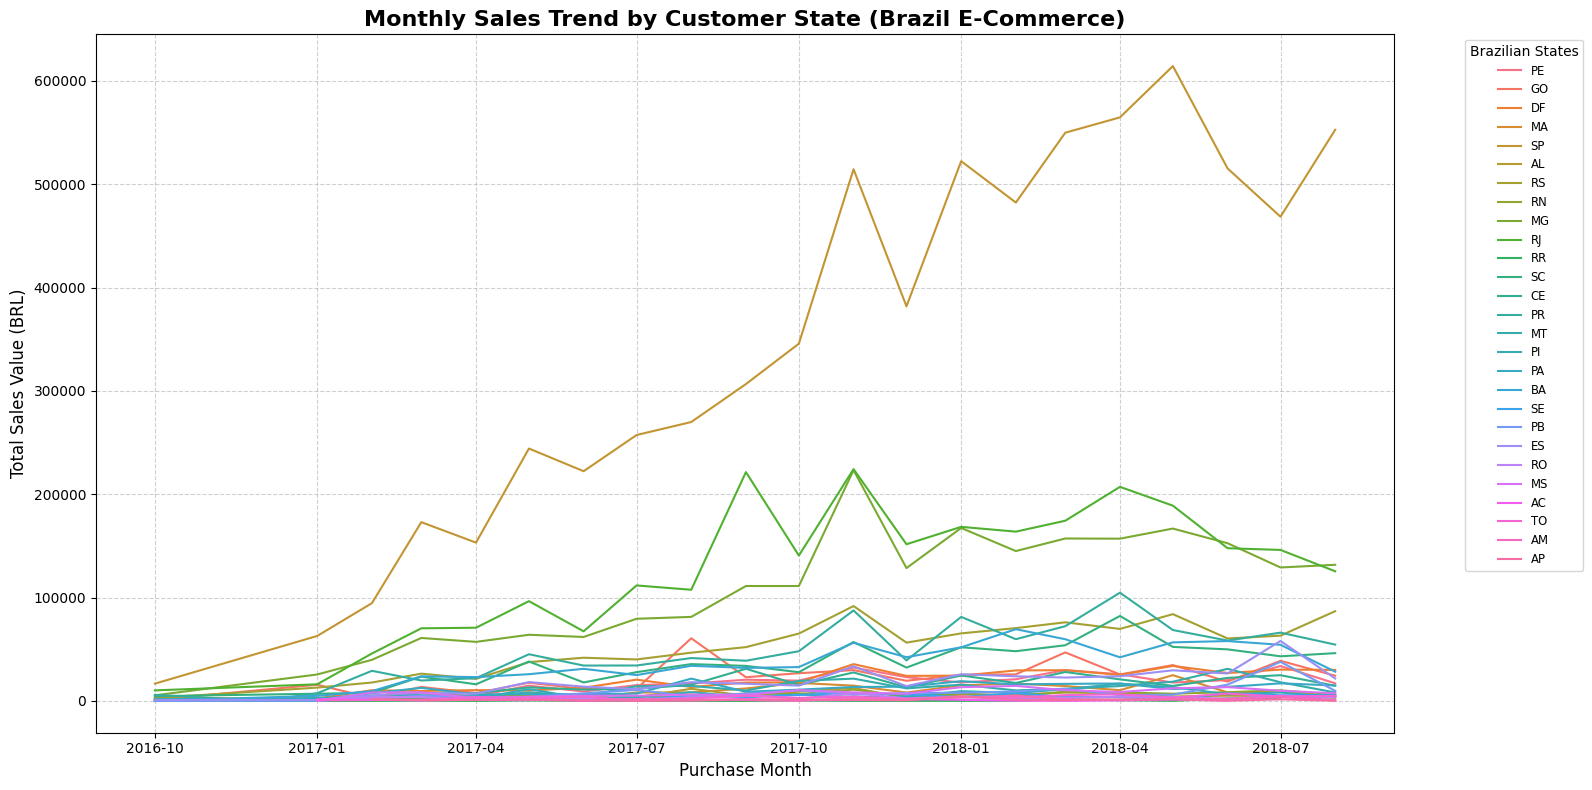

In [21]:
data_sales = data_sales.sort_values(by='month/year_of_purchase')

plt.figure(figsize=(16, 8))
sns.lineplot(data=data_sales,x='month/year_of_purchase',y='payment_value',hue='customer_state',legend='brief')

plt.title('Monthly Sales Trend by Customer State (Brazil E-Commerce)', fontsize=16, fontweight='bold')
plt.xlabel('Purchase Month', fontsize=12)
plt.ylabel('Total Sales Value (BRL)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Brazilian States', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

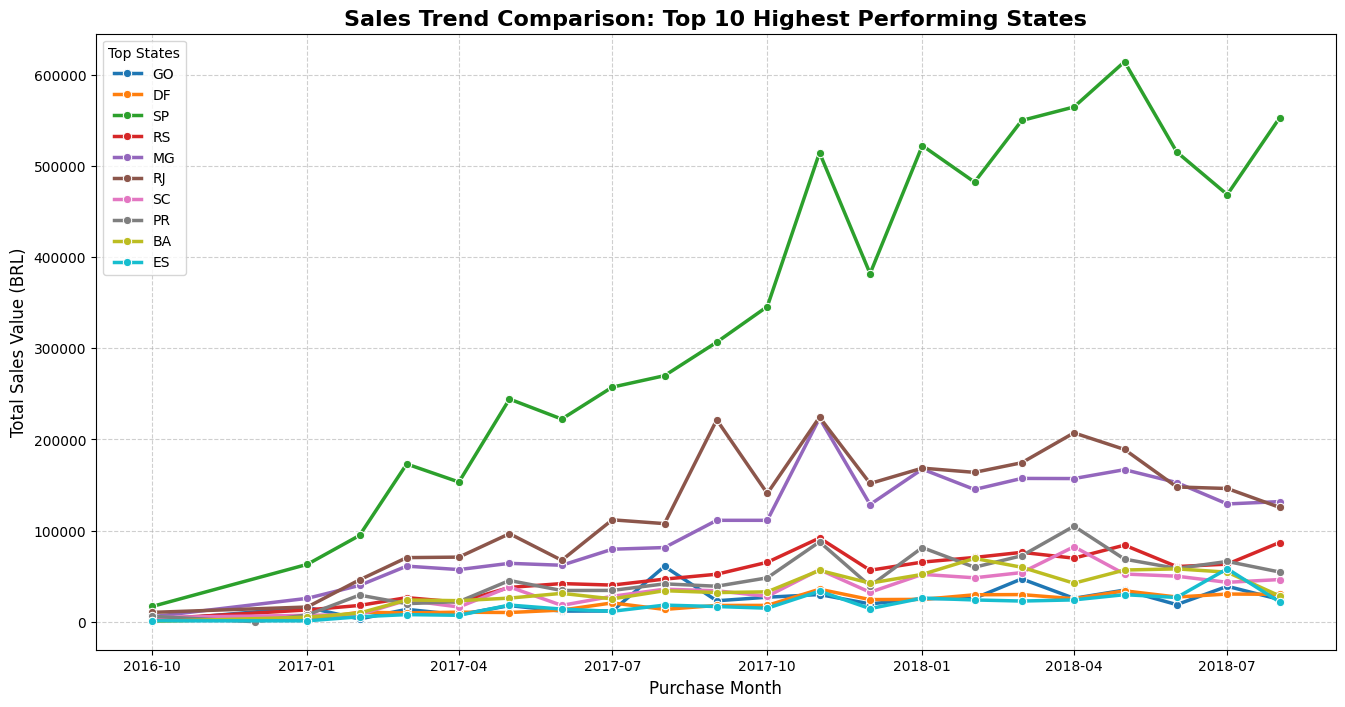

In [22]:
top_10_states = data_sales.groupby('customer_state')['payment_value'].sum().nlargest(10).index
top_10_data = data_sales[data_sales['customer_state'].isin(top_10_states)]

plt.figure(figsize=(16, 8))
sns.lineplot(data=top_10_data,x='month/year_of_purchase',y='payment_value',hue='customer_state',marker='o',linewidth=2.5)

plt.title('Sales Trend Comparison: Top 10 Highest Performing States', fontsize=16, fontweight='bold')
plt.xlabel('Purchase Month', fontsize=12)
plt.ylabel('Total Sales Value (BRL)', fontsize=12)
plt.legend(title='Top States', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Coba dulu tidak running ini untuk lihat hasil

In [23]:
treatment_time = pd.to_datetime("2018-01-01")

In [24]:
other_state = top_10_states.to_list()
other_state = [state for state in other_state if state != "RJ"]
formula = "RJ ~ 0 + " + " + ".join(other_state)
formula

'RJ ~ 0 + SP + MG + RS + PR + BA + SC + GO + DF + ES'

Output()

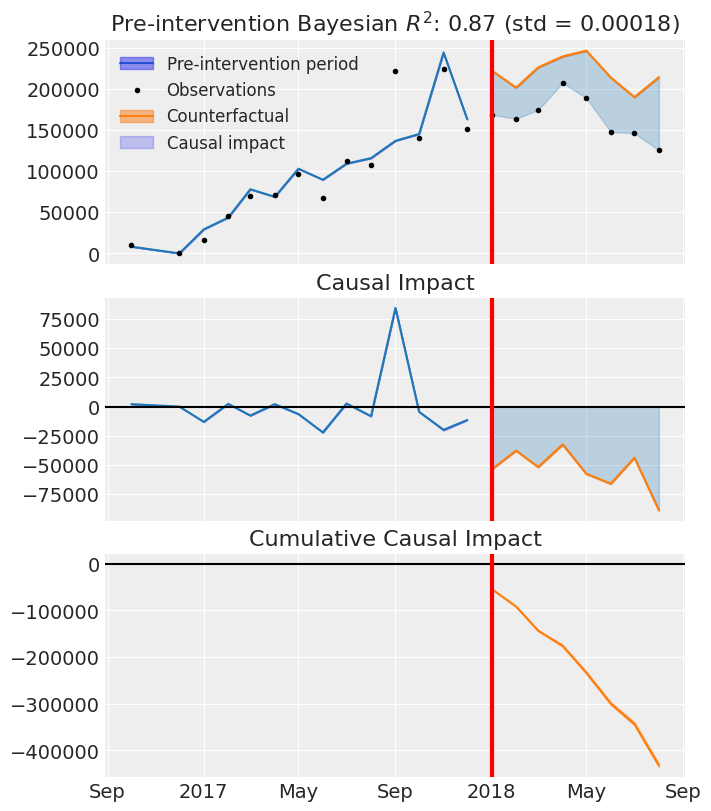

In [25]:
result = cp.SyntheticControl(data_sales_state,treatment_time,treated_units=["RJ"],control_units=other_state,model=cp.pymc_models.WeightedSumFitter())
fig, ax = result.plot(plot_limit=None)
plt.show()

In [26]:
try:
    weights = result.idata.posterior["w"].mean(dim=("chain", "draw"))
except KeyError:
    weights = result.idata.posterior["beta"].mean(dim=("chain", "draw"))
weights_df = weights.to_pandas()
if isinstance(weights_df, pd.DataFrame):
    first_col = weights_df.columns[0]
    weights_sorted = weights_df.sort_values(by=first_col, ascending=False)
else:
    weights_sorted = weights_df.sort_values(ascending=False)
print(weights_sorted)

coeffs               SP        MG        RS        PR        BA        SC  \
treated_units                                                               
RJ             0.264459  0.398577  0.000391  0.000129  0.000204  0.335008   

coeffs               GO        DF        ES  
treated_units                                
RJ             0.000325  0.000513  0.000394  


State  Contribution (%)
   MG         39.857704
   SC         33.500835
   SP         26.445867
   DF          0.051269
   ES          0.039377
   RS          0.039144
   GO          0.032536
   BA          0.020414
   PR          0.012853


/tmp/ipykernel_1138/3407078791.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=clean_weights, x='Contribution (%)', y='State', palette=colors)


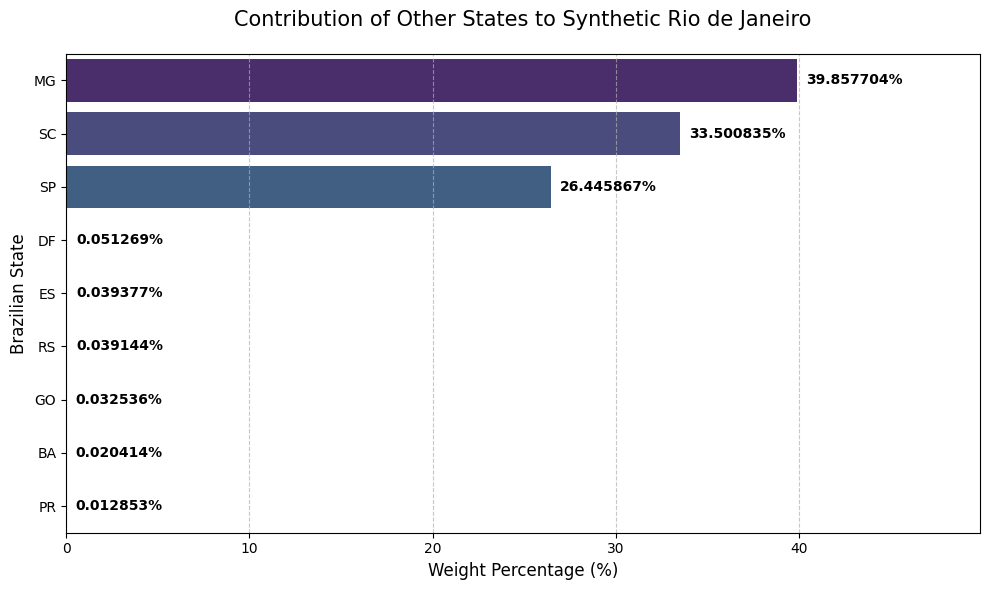

In [27]:
weights_series = weights_df.loc["RJ"].sort_values(ascending=False)
clean_weights = pd.DataFrame({
    'State': weights_series.index,
    'Contribution (%)': (weights_series.values * 100).round(6)
})
plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(clean_weights))
ax = sns.barplot(data=clean_weights, x='Contribution (%)', y='State', palette=colors)
for i, v in enumerate(clean_weights['Contribution (%)']):
    ax.text(v + 0.5, i, f'{v}%', color='black', va='center', fontweight='bold')

plt.title('Contribution of Other States to Synthetic Rio de Janeiro', fontsize=15, pad=20)
plt.xlabel('Weight Percentage (%)', fontsize=12)
plt.ylabel('Brazilian State', fontsize=12)
plt.xlim(0, max(clean_weights['Contribution (%)']) + 10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

print(clean_weights.to_string(index=False))